In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import timm
import SimpleITK as sitk
import cv2

# Read input

In [47]:
import pandas as pd

# Load metadata safely
metadata_path = '/kaggle/input/prostate-cancer-pi-cai-dataset/Metadata with lesion info.csv'
metadata = pd.read_csv(metadata_path)

# Drop unnamed index column if it exists
if 'Unnamed: 0' in metadata.columns:
    metadata.drop(columns=['Unnamed: 0'], inplace=True)

# Ensure IDs are strings (important for consistent merging)
metadata['patient_id'] = metadata['patient_id'].astype(str)
metadata['study_id'] = metadata['study_id'].astype(str)

# Create unique patient-case IDs
metadata['pcID'] = metadata['patient_id'] + "_" + metadata['study_id']

print(f"✅ Metadata loaded successfully: {metadata.shape[0]} records")
display(metadata.head())

✅ Metadata loaded successfully: 871 records


,patient_id,study_id,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,pcID
0,10000,1000000,0.032648,0.018868,0.230769,1,0,0,0,0,0,10000_1000000
1,10003,1000003,0.056351,0.024673,0.305430,1,0,0,0,0,0,10003_1000003
2,10004,1000004,0.033989,0.013062,0.334842,2,0,0,0,0,0,10004_1000004
3,10005,1000005,0.052326,0.033382,0.212670,2,4,3,7,3,1,10005_1000005
4,10006,1000006,0.025939,0.031930,0.104072,2,3,3,6,1,0,10006_1000006


# Define the image processing functions

In [48]:
def display_img(img, title="MRI Slice"):
    """Display the middle slice of a 3D MRI image"""
    img_arr = sitk.GetArrayFromImage(img)
    mid_slice = img_arr.shape[0] // 2
    plt.figure(figsize=(5, 5))
    plt.imshow(img_arr[mid_slice], cmap='gray')
    plt.axis('off')
    plt.title(f'{title} | Slice {mid_slice} | Shape: {img_arr.shape[1:]}')
    plt.show()


def select_slice(img, num_slices):
    """Select centered subset of slices"""
    size = img.GetSize()
    depth = size[2]
    if num_slices >= depth:
        print("⚠️ Requested slices exceed depth — returning full volume.")
        return img
    start_slice = max((depth - num_slices) // 2, 0)
    return sitk.RegionOfInterest(img, [size[0], size[1], num_slices], [0, 0, start_slice])


def zero_pad(img, trg_height, trg_width):
    """Zero-pad to target spatial size"""
    img_arr = sitk.GetArrayFromImage(img)
    h, w = img_arr.shape[1], img_arr.shape[2]
    pad_h = max((trg_height - h) // 2, 0)
    pad_w = max((trg_width - w) // 2, 0)
    padded_img = np.pad(img_arr, ((0, 0), (pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    return sitk.GetImageFromArray(padded_img)


def interpolate(img, trg_height, trg_width):
    """Resize each slice to target dimensions"""
    img_arr = sitk.GetArrayFromImage(img)
    resized_slices = [cv2.resize(slice, (trg_width, trg_height), interpolation=cv2.INTER_CUBIC)
                      for slice in img_arr]
    resized_arr = np.stack(resized_slices, axis=0)
    return sitk.GetImageFromArray(resized_arr)


def normalize(img_arr):
    """Normalize image to [0, 1]"""
    img_max = img_arr.max()
    return img_arr / (img_max + 1e-8)


def standardization(image):
    """Z-score standardization"""
    mean, std = np.mean(image), np.std(image)
    return (image - mean) / std if std != 0 else image


# Extract the images from dataset

In [49]:
import os, shutil

root_dir = '/kaggle/input/prostate-cancer-pi-cai-dataset'
output_dir = '/kaggle/working/output_directory'
os.makedirs(output_dir, exist_ok=True)

num_cases = 0
copied_cases = set()

for main_folder in os.listdir(root_dir):
    main_folder_path = os.path.join(root_dir, main_folder)
    
    if os.path.isdir(main_folder_path):
        for patient_folder in os.listdir(main_folder_path):
            patient_folder_path = os.path.join(main_folder_path, patient_folder)
            
            if os.path.isdir(patient_folder_path):
                for file_name in os.listdir(patient_folder_path):
                    # Extract patient_case_id (first two parts or first three if needed)
                    parts = file_name.split('_')
                    if len(parts) >= 2:
                        patient_case_id = f"{parts[0]}_{parts[1]}"
                        # Optionally include the 3rd part if that’s how IDs appear in metadata
                        if patient_case_id not in pcID and len(parts) >= 3:
                            patient_case_id = f"{parts[0]}_{parts[1]}_{parts[2]}"

                        # Match with metadata IDs
                        if patient_case_id in pcID:
                            output_subdir = os.path.join(output_dir, patient_case_id)
                            os.makedirs(output_subdir, exist_ok=True)

                            # Copy only axial (skip sagittal/coronal)
                            if not (file_name.endswith('_sag.mha') or file_name.endswith('_cor.mha')):
                                src = os.path.join(patient_folder_path, file_name)
                                dst = os.path.join(output_subdir, file_name)
                                shutil.copy(src, dst)

                                if patient_case_id not in copied_cases:
                                    copied_cases.add(patient_case_id)
                                    num_cases += 1

print("✅ Total cases copied:", num_cases)
print("✅ Unique patient-case IDs found:", len(copied_cases))


✅ Total cases copied: 871
✅ Unique patient-case IDs found: 871


In [50]:
for case_folder in os.listdir(output_dir):
    case_folder_path = os.path.join(output_dir,case_folder)
    
    if os.path.isdir(case_folder_path): 
        for file_name in os.listdir(case_folder_path):
            file_path = os.path.join(case_folder_path,file_name)
            img = sitk.ReadImage(file_path)
            resized_img = interpolate(select_slice(img,16),224,224)
            sitk.WriteImage(resized_img, file_path)


metadata['PatientID_CaseID'] = metadata['patient_id'].astype(str) + "_" + metadata['study_id'].astype(str)
metadata.head()

⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested slices exceed depth — returning full volume.
⚠️ Requested s

,patient_id,study_id,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,pcID,PatientID_CaseID
0,10000,1000000,0.032648,0.018868,0.230769,1,0,0,0,0,0,10000_1000000,10000_1000000
1,10003,1000003,0.056351,0.024673,0.305430,1,0,0,0,0,0,10003_1000003,10003_1000003
2,10004,1000004,0.033989,0.013062,0.334842,2,0,0,0,0,0,10004_1000004,10004_1000004
3,10005,1000005,0.052326,0.033382,0.212670,2,4,3,7,3,1,10005_1000005,10005_1000005
4,10006,1000006,0.025939,0.031930,0.104072,2,3,3,6,1,0,10006_1000006,10006_1000006


# Apply augmentation

In [51]:
import albumentations as A
import numpy as np
import os
import SimpleITK as sitk
import pandas as pd

# Augmentation mapping per ISUP grade
aug_grades = {3: 1, 4: 5, 5: 3}  # ISUP grade → number of augmentations

# Augmentation pipeline (based on Table 2)
medical_aug= A.Compose([
    A.Rotate(limit=45, p=0.5),  # Rotation: 0–45°
    A.ShiftScaleRotate(shift_limit=0.25, scale_limit=0.25, p=0.5),  # Shift & Zoom
    A.Affine(shear={'x': (-25, 25)}, p=0.3), 
    A.Affine(shear={'y': (-25, 25)}, p=0.3), 
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=(0.5, 2.0), contrast_limit=0.0, p=0.4),
])

# Apply augmentations to a single 2D slice
def apply_augmentations(image_slice):
    image_slice = np.clip(image_slice, 0, None)  # Remove negatives
    augmented = medical_aug(image=image_slice)['image']
    return augmented

# Loop through metadata
for idx, row in metadata.iterrows():
    grade = row['case_ISUP']
    if grade not in aug_grades:
        continue

    case_id = row['PatientID_CaseID']
    case_folder = os.path.join(output_dir, case_id)

    if not os.path.exists(case_folder):
        continue

    # Read original images once
    original_images = {}
    for modality in ['t2w', 'adc', 'hbv']:
        original_file = os.path.join(case_folder, f"{case_id}_{modality}.mha")
        if os.path.exists(original_file):
            original_images[modality] = sitk.ReadImage(original_file)

    # Apply augmentations
    for i in range(aug_grades[grade]):
        aug_folder = os.path.join(output_dir, f"{case_id}_aug_{i+1:03d}")
        os.makedirs(aug_folder, exist_ok=True)

        for modality, image in original_images.items():
            image_array = sitk.GetArrayFromImage(image)  # Shape: (D, H, W)
            D, H, W = image_array.shape

            augmented_slices = []
            for d in range(D):
                slice_2d = image_array[d]
                augmented_slice = apply_augmentations(slice_2d)
                augmented_slices.append(augmented_slice)

            # Reconstruct 3D image
            aug_sitk = sitk.GetImageFromArray(np.array(augmented_slices))
            aug_sitk.CopyInformation(image)

            # Save file
            aug_file = os.path.join(aug_folder, f"{case_id}_aug_{i+1:03d}_{modality}.mha")
            sitk.WriteImage(aug_sitk, aug_file)


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [52]:
image_data = []

# Iterate through patient folders, including augmented ones
for patient_case in os.listdir(output_dir):
    patient_dir = os.path.join(output_dir, patient_case)
    
    # Skip if not a directory
    if not os.path.isdir(patient_dir):
        continue
    
    # Extract the original case ID (handles both original & augmented cases)
    base_case_id = patient_case.split('_aug_')[0]  # Extract original case ID
    
    # Check if base case ID exists in the metadata
    if base_case_id in metadata['PatientID_CaseID'].values:
        # Fetch metadata for this patient
        case_data = metadata.loc[metadata['PatientID_CaseID'] == base_case_id].iloc[0]
        
        # Iterate through files in the case folder
        for file_name in os.listdir(patient_dir):
            file_path = os.path.join(patient_dir, file_name)
            
            if file_name.endswith('.mha'):
                # Extract modality (adc, hbv, t2w)
                modality = file_name.split('_')[-1].split('.')[0]
                
                # Determine if it's an augmented image
                is_augmented = "_aug_" in patient_case  # Check if it's augmented
                aug_suffix = ""
                
                if is_augmented:
                    # Assign a unique augmented name (10005_100005_a1, a2, etc.)
                    aug_id = patient_case.split('_aug_')[-1]  # Extract augmentation number
                    patient_case_name = f"{base_case_id}_a{int(aug_id):02d}"
                else:
                    patient_case_name = base_case_id  # Keep original ID for non-augmented data

                # Append mapping information
                image_data.append({
                    'ImagePath': file_path,
                    'PatientID_CaseID': patient_case_name,  # Modified for augmented cases
                    'Augmented': is_augmented,  # True if it's an augmented image
                    'Modality': modality,
                    'psa': case_data['psa'],
                    'psad': case_data['psad'],
                    'prostate_volume': case_data['prostate_volume'],
                    'num_lesions': case_data['num_lesions'],
                    'max_prim_score': case_data['max_prim_score'],
                    'max_sec_score': case_data['max_sec_score'],
                    'max_gleason_scores': case_data['max_gleason_scores'],
                    'case_ISUP': case_data['case_ISUP'],
                    'case_csPCa': case_data['case_csPCa']
                })

# Convert list to DataFrame
image_df = pd.DataFrame(image_data)
image_df.head(10)

,ImagePath,PatientID_CaseID,Augmented,Modality,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa
0,/kaggle/working/output_directory/10515_1000525...,10515_1000525,False,hbv,0.042934,0.029028,0.194570,3,3,4,7,2,1
1,/kaggle/working/output_directory/10515_1000525...,10515_1000525,False,adc,0.042934,0.029028,0.194570,3,3,4,7,2,1
2,/kaggle/working/output_directory/10515_1000525...,10515_1000525,False,t2w,0.042934,0.029028,0.194570,3,3,4,7,2,1
3,/kaggle/working/output_directory/10557_1000569...,10557_1000569,False,adc,0.033542,0.017417,0.253394,1,0,0,0,0,0
4,/kaggle/working/output_directory/10557_1000569...,10557_1000569,False,t2w,0.033542,0.017417,0.253394,1,0,0,0,0,0
5,/kaggle/working/output_directory/10557_1000569...,10557_1000569,False,hbv,0.033542,0.017417,0.253394,1,0,0,0,0,0
6,/kaggle/working/output_directory/10322_1000328...,10322_1000328_a02,True,hbv,0.039356,0.039187,0.126697,1,4,4,8,4,1
7,/kaggle/working/output_directory/10322_1000328...,10322_1000328_a02,True,adc,0.039356,0.039187,0.126697,1,4,4,8,4,1
8,/kaggle/working/output_directory/10322_1000328...,10322_1000328_a02,True,t2w,0.039356,0.039187,0.126697,1,4,4,8,4,1
9,/kaggle/working/output_directory/10184_1000187...,10184_1000187,False,hbv,0.092129,0.024673,0.524887,1,0,0,0,0,0


In [53]:
image_df.shape
round(image_df['case_csPCa'].value_counts()/3)
round(image_df['case_ISUP'].value_counts()/3)

case_ISUP
0    316.0
2    198.0
1    192.0
5    188.0
4    186.0
3    174.0
Name: count, dtype: float64

# Feature extraction

In [54]:
from transformers import ViTFeatureExtractor, TFAutoModel
from PIL import Image
import math
import gc

vit_model = TFAutoModel.from_pretrained("google/vit-base-patch16-224-in21k")
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")

def extract_vit_features(img_path, csv_file, is_first_entry=False):
    try:
        # Load image with SimpleITK and convert to RGB
        img = sitk.ReadImage(img_path)
        img_array = sitk.GetArrayFromImage(img)
        if len(img_array.shape) == 3:
            img_array = np.transpose(img_array, (1, 2, 0))
            img_array = img_array[:, :, :3]

        img_array = img_array.astype(np.uint8)
        pil_img = Image.fromarray(img_array)

        # Preprocess
        inputs = feature_extractor(images=pil_img, return_tensors="tf")
        outputs = vit_model(**inputs)

        # Take [CLS] token as the feature vector
        cls_token = outputs.last_hidden_state[:, 0, :].numpy().flatten().tolist()

        df = pd.DataFrame([[img_path, cls_token]], columns=['ImagePath', 'Features'])
        df.to_csv(csv_file, mode='a', header=is_first_entry, index=False)

        del img, img_array, pil_img, inputs, outputs, cls_token, df
        gc.collect()

    except Exception as e:
        print(f"Error processing {img_path}: {e}")


def process_images(image_df, batch_size, output_csv):
    batch_count = 0
    total_batches = math.ceil(len(image_df) / batch_size)

    # Ensure CSV is empty before writing
    if os.path.exists(output_csv):
        os.remove(output_csv)

    for start_idx in range(0, len(image_df), batch_size):
        end_idx = start_idx + batch_size
        batch_df = image_df.iloc[start_idx:end_idx]

        for idx, row in batch_df.iterrows():
            img_path = row['ImagePath']
            is_first_entry = (batch_count == 0 and idx == start_idx)  # True only for the first row of first batch
            extract_vit_features(img_path, output_csv, is_first_entry)

        batch_count += 1
        print(f"Completed {batch_count}/{total_batches} batches")

        gc.collect()  


batch_size = 8
output_csv = '/kaggle/working/image_features.csv'

process_images(image_df, batch_size, output_csv)

features_df = pd.read_csv(output_csv)
print("Feature extraction complete!")



All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.
/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
I0000 00:00:1761541056.688798      36 cuda_dnn.cc:529] Loaded cuDNN version 90300


Completed 1/471 batches
Completed 2/471 batches
Completed 3/471 batches
Completed 4/471 batches
Completed 5/471 batches
Completed 6/471 batches
Completed 7/471 batches
Completed 8/471 batches
Completed 9/471 batches
Completed 10/471 batches
Completed 11/471 batches
Completed 12/471 batches
Completed 13/471 batches
Completed 14/471 batches
Completed 15/471 batches
Completed 16/471 batches
Completed 17/471 batches
Completed 18/471 batches
Completed 19/471 batches
Completed 20/471 batches
Completed 21/471 batches
Completed 22/471 batches
Completed 23/471 batches
Completed 24/471 batches
Completed 25/471 batches
Completed 26/471 batches
Completed 27/471 batches
Completed 28/471 batches
Completed 29/471 batches
Completed 30/471 batches
Completed 31/471 batches
Completed 32/471 batches
Completed 33/471 batches
Completed 34/471 batches
Completed 35/471 batches
Completed 36/471 batches
Completed 37/471 batches
Completed 38/471 batches
Completed 39/471 batches
Completed 40/471 batches
Completed

# Make the final metadata

In [55]:
img_features_df = pd.merge(image_df,features_df,how = 'inner',on='ImagePath')
img_features_df["Features"] = img_features_df["Features"].apply(lambda x: np.array(x))
img_features_df.head()

,ImagePath,PatientID_CaseID,Augmented,Modality,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,Features
0,/kaggle/working/output_directory/10515_1000525...,10515_1000525,False,hbv,0.042934,0.029028,0.194570,3,3,4,7,2,1,"[-0.03896584361791611, 0.02041853964328766, -0..."
1,/kaggle/working/output_directory/10515_1000525...,10515_1000525,False,adc,0.042934,0.029028,0.194570,3,3,4,7,2,1,"[-0.04307549074292183, -0.25520238280296326, -..."
2,/kaggle/working/output_directory/10515_1000525...,10515_1000525,False,t2w,0.042934,0.029028,0.194570,3,3,4,7,2,1,"[-0.10401733964681625, -0.017186351120471954, ..."
3,/kaggle/working/output_directory/10557_1000569...,10557_1000569,False,adc,0.033542,0.017417,0.253394,1,0,0,0,0,0,"[-0.014201928861439228, 0.21168753504753113, -..."
4,/kaggle/working/output_directory/10557_1000569...,10557_1000569,False,t2w,0.033542,0.017417,0.253394,1,0,0,0,0,0,"[-0.23366546630859375, 0.07870767265558243, 0...."


In [56]:
import ast
img_features_df.shape
img_features_df.info()
def convert(x):
    """If the feature vector is written as a string to the csv, then convert it to numpy array"""
    if isinstance(x, np.ndarray):  
        return x
    elif isinstance(x, str):  
        try:
            return np.array(ast.literal_eval(x), dtype=np.float16)
        except (ValueError, SyntaxError):  
            return None  
    else:
        return None  

img_features_df['Features'] = img_features_df['Features'].apply(convert)

def concatenate_features(df):
    """Stacks the feature vector of all modalities for a particular case"""
    grouped = df.groupby('PatientID_CaseID')
    concatenated_data = []

    for patient_id, patient_data in grouped:
        features = [f for f in patient_data['Features'].values]
        concatenated_features = np.hstack(features) if features else None    
        concatenated_data.append({
            'PatientID_CaseID': patient_id,
            'Concatenated_Features': concatenated_features})

    return pd.DataFrame(concatenated_data)


concatenated_features_df = concatenate_features(img_features_df)


columns_to_keep = [col for col in img_features_df.columns if col not in ['Modality','Features', 'Augmented', 'ImagePath']]
image_metadata_df = img_features_df[columns_to_keep].drop_duplicates()


metadata_final = pd.merge(image_metadata_df, concatenated_features_df, how='inner', on='PatientID_CaseID')


metadata_final['PatientID_CaseID'] = metadata_final['PatientID_CaseID'].apply(
    lambda x: x if '_aug_' not in x else f"{x}_a1"
)

metadata_final.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ImagePath           3762 non-null   object 
 1   PatientID_CaseID    3762 non-null   object 
 2   Augmented           3762 non-null   bool   
 3   Modality            3762 non-null   object 
 4   psa                 3762 non-null   float64
 5   psad                3762 non-null   float64
 6   prostate_volume     3762 non-null   float64
 7   num_lesions         3762 non-null   int64  
 8   max_prim_score      3762 non-null   int64  
 9   max_sec_score       3762 non-null   int64  
 10  max_gleason_scores  3762 non-null   int64  
 11  case_ISUP           3762 non-null   int64  
 12  case_csPCa          3762 non-null   int64  
 13  Features            3762 non-null   object 
dtypes: bool(1), float64(3), int64(6), object(4)
memory usage: 385.9+ KB


,PatientID_CaseID,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,Concatenated_Features
0,10515_1000525,0.042934,0.029028,0.194570,3,3,4,7,2,1,"[-0.03897, 0.02042, -0.05908, 0.06107, -0.2722..."
1,10557_1000569,0.033542,0.017417,0.253394,1,0,0,0,0,0,"[-0.0142, 0.2117, -0.1346, -0.010376, -0.0342,..."
2,10322_1000328_a02,0.039356,0.039187,0.126697,1,4,4,8,4,1,"[-0.03247, -0.1412, -0.04144, -0.179, 0.0881, ..."
3,10184_1000187,0.092129,0.024673,0.524887,1,0,0,0,0,0,"[-0.0963, -0.04556, -0.1595, -0.0712, -0.1085,..."
4,11349_1001372,0.024150,0.011611,0.276018,1,0,0,0,0,0,"[-0.07495, -0.015526, 0.1242, 0.272, -0.0709, ..."
5,11159_1001182,0.042934,0.023222,0.389140,1,0,0,0,0,0,"[0.09216, -0.2311, -0.00958, 0.2659, 0.08295, ..."
6,10810_1000826,0.042487,0.042090,0.131222,2,3,4,7,2,1,"[-0.013, 0.1589, -0.01787, 0.01192, -0.0659, 0..."
7,10393_1000399,0.019231,0.017417,0.149321,3,3,4,7,2,1,"[0.015205, 0.03757, -0.05936, 0.252, 0.10223, ..."
8,10069_1000069,0.026386,0.005806,0.542986,1,0,0,0,0,0,"[-0.137, 0.013336, -0.0308, 0.0888, 0.10724, -..."
9,10831_1000847,0.021467,0.007257,0.348416,2,3,3,6,1,0,"[-0.1444, -0.1516, -0.0755, 0.0906, -0.02303, ..."


In [57]:
metadata_final.info()
metadata_final.shape
metadata_final['Concatenated_Features'][0].shape
feature_lengths = metadata_final['Concatenated_Features'].apply(lambda x: len(x))
print("Unique lengths of feature vectors:", feature_lengths.unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PatientID_CaseID       1254 non-null   object 
 1   psa                    1254 non-null   float64
 2   psad                   1254 non-null   float64
 3   prostate_volume        1254 non-null   float64
 4   num_lesions            1254 non-null   int64  
 5   max_prim_score         1254 non-null   int64  
 6   max_sec_score          1254 non-null   int64  
 7   max_gleason_scores     1254 non-null   int64  
 8   case_ISUP              1254 non-null   int64  
 9   case_csPCa             1254 non-null   int64  
 10  Concatenated_Features  1254 non-null   object 
dtypes: float64(3), int64(6), object(2)
memory usage: 107.9+ KB
Unique lengths of feature vectors: [2304]


In [58]:
feature_lengths = metadata_final['Concatenated_Features'].apply(lambda x: len(x))
length_counts = feature_lengths.value_counts()
print(length_counts)

Concatenated_Features
2304    1254
Name: count, dtype: int64


In [59]:
# Assuming 'patientID_caseID' is the column name for patient-case identifiers
incorrect_entries = metadata_final[metadata_final['Concatenated_Features'].apply(lambda x: len(x) != 2304)]

# Display the patientID_caseID of the incorrect entry
print(incorrect_entries[['PatientID_CaseID', 'Concatenated_Features']])

Empty DataFrame
Columns: [PatientID_CaseID, Concatenated_Features]
Index: []


In [60]:
metadata_final = metadata_final[metadata_final['Concatenated_Features'].apply(lambda x: len(x) == 2304)].reset_index(drop=True)

print("Filtered dataset shape:", metadata_final.shape)

Filtered dataset shape: (1254, 11)


In [61]:
feature_lengths = metadata_final['Concatenated_Features'].apply(lambda x: len(x))
length_counts = feature_lengths.value_counts()
print(length_counts)

Concatenated_Features
2304    1254
Name: count, dtype: int64


# Train the model

In [62]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf


# -------- Data preparation --------
feature_vector = np.array(metadata_final['Concatenated_Features'].tolist())
sc = StandardScaler()
feature_vector_scaled = sc.fit_transform(feature_vector)

metadata_columns = ['psa', 'psad', 'prostate_volume','num_lesions','max_prim_score','max_sec_score','max_gleason_scores']
metadata_values = metadata_final[metadata_columns].values
metadata_scaled = sc.fit_transform(metadata_values)

x = np.hstack((metadata_scaled, feature_vector_scaled)) 

y = metadata_final['case_csPCa'].values 
y = LabelEncoder().fit_transform(y)

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold = 1
acc_scores = []
auc_scores = []

for train_index, val_index in skf.split(x, y):
    print(f"\n Fold {fold}")

    x_train, x_val = x[train_index], x[val_index]
    y_train, y_val = y[train_index], y[val_index]

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(class_weights))

    model = Sequential([
    Input(shape=(x.shape[1],)),
    BatchNormalization(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.48),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])


    model.compile(optimizer=Adam(learning_rate=0.05),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ]

    model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=30,
        batch_size=36,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=0
    )

    val_loss, val_acc,val_auc = model.evaluate(x_val, y_val, verbose=0)
    y_pred_proba = model.predict(x_val, verbose=0)

    print(f" Fold {fold} Accuracy: {val_acc:.4f} | AUC: {val_auc:.4f}")

    acc_scores.append(val_acc)
    auc_scores.append(val_auc)
    fold += 1

# -------- Final report --------
print("\n Cross-Validation Results:")
print(f"Average Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"Average AUC:      {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")



 Fold 1


I0000 00:00:1761543701.671286     178 service.cc:148] XLA service 0x79cd20011a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761543701.672121     178 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761543704.154372     178 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 Fold 1 Accuracy: 0.9004 | AUC: 0.9726

 Fold 2
 Fold 2 Accuracy: 0.8685 | AUC: 0.9481

 Fold 3
 Fold 3 Accuracy: 0.8964 | AUC: 0.9480

 Fold 4
 Fold 4 Accuracy: 0.9283 | AUC: 0.9803

 Fold 5
 Fold 5 Accuracy: 0.9320 | AUC: 0.9856

 Cross-Validation Results:
Average Accuracy: 0.9051 ± 0.0232
Average AUC:      0.9669 ± 0.0160


In [63]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib
import warnings
from tensorflow.keras import regularizers
warnings.filterwarnings('ignore')


feature_vector = np.array(metadata_final['Concatenated_Features'].tolist())
sc = StandardScaler()
feature_vector_scaled = sc.fit_transform(feature_vector)
joblib.dump(sc, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

metadata_columns = ['psa', 'psad', 'prostate_volume','num_lesions','max_prim_score','max_sec_score','max_gleason_scores']
metadata_values = metadata_final[metadata_columns].values
metadata_scaled = sc.fit_transform(metadata_values)

x = np.hstack((metadata_scaled, feature_vector_scaled)) 

y = metadata_final[['case_ISUP','case_csPCa']].values
le = LabelEncoder()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True, random_state=42, stratify=y[:,1])

case_ISUP = y_test[:,0]
case_csPCa = y_test[:,1]

y_train = y_train[:,1]
y_test = y_test[:,1]

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))


model = Sequential([
    Input(shape=(x.shape[1],)),
    BatchNormalization(),

    Dense(256, kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32),
    LeakyReLU(),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=1e-6, verbose=1, mode='max')
]

history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

train_loss, train_acc, train_auc = model.evaluate(x_train, y_train, verbose=0)
print(f"\n✅ Train Accuracy: {train_acc:.4f} | Train AUC: {train_auc:.4f}")




✅ Scaler saved as 'scaler.pkl'
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - accuracy: 0.6385 - auc: 0.7188 - loss: 1.3149 - val_accuracy: 0.7015 - val_auc: 0.8121 - val_loss: 1.2382 - learning_rate: 0.0010
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7263 - auc: 0.8223 - loss: 1.1473 - val_accuracy: 0.7711 - val_auc: 0.8529 - val_loss: 1.1356 - learning_rate: 0.0010
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7798 - auc: 0.8939 - loss: 1.0496 - val_accuracy: 0.7711 - val_auc: 0.8581 - val_loss: 1.1435 - learning_rate: 0.0010
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8316 - auc: 0.9361 - loss: 0.9460 - val_accuracy: 0.8308 - val_auc: 0.9021 - val_loss: 1.0055 - learning_rate: 0.0010
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8820 - auc: 0.9632 - loss: 0.8625 - val_accuracy: 0.7662 - val_auc: 0.8556 - val_loss: 1.1501 - learning_rate: 0.0010
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

# Testing the model

In [64]:
from sklearn.metrics import classification_report, roc_auc_score

y_probs = model.predict(x_test)
y_pred = (y_probs >= 0.5).astype(int)
print("Classification Report:\n", classification_report(y_test, y_pred))
final_auc = roc_auc_score(y_test, y_probs)
print(f"\n Final Test AUC: {final_auc:.4f}")
loss = model.evaluate(x_test, y_test, verbose=0)[0]
print(f"Test Loss: {loss:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.81      0.77       102
           1       0.86      0.80      0.83       149

    accuracy                           0.80       251
   macro avg       0.80      0.81      0.80       251
weighted avg       0.81      0.80      0.81       251


 Final Test AUC: 0.9070
Test Loss: 1.0072


# Confusion matrix

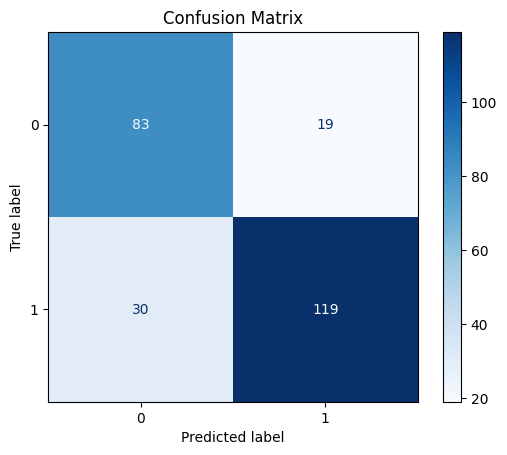

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = (y_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()